<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

In [11]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)



(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


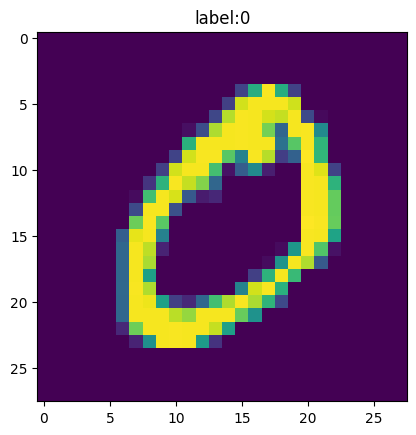

In [12]:
img=x_train[1,:,:]
label=y_train[1]
plt.imshow(img)

plt.title(f"label:{label}")
plt.show()

# **data preprocessing**

In [13]:
#normalize and reshape
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float32')/255
#one hot encoding labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
#

(60000, 28, 28, 1)
(10000, 28, 28, 1)
(60000, 10, 2, 2, 2)
(10000, 10, 2, 2, 2)


# **model Building**
build a cnn model using keras sequentiakl api

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# **model compilation**

In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# **model training**

In [17]:
history=model.fit(x_train, y_train, epochs=10,batch_size=128,validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7757 - loss: 0.7043 - val_accuracy: 0.9759 - val_loss: 0.0810
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9641 - loss: 0.1210 - val_accuracy: 0.9816 - val_loss: 0.0604
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9735 - loss: 0.0857 - val_accuracy: 0.9864 - val_loss: 0.0451
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9797 - loss: 0.0685 - val_accuracy: 0.9879 - val_loss: 0.0413
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9825 - loss: 0.0606 - val_accuracy: 0.9890 - val_loss: 0.0386
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9863 - loss: 0.0462 - val_accuracy: 0.9896 - val_loss: 0.0378
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9900 - val_loss: 0.0348
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.

# **model evaluation**

In [19]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Tested Acc:",test_acc)
print("Tested Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9885 - loss: 0.0353
Tested Acc: 0.991599977016449
Tested Loss: 0.026452582329511642


# **model prediction**

In [27]:
pred=model.predict(x_test[:15])
pred_classes=np.argmax(pred,axis=1)
act_classes=np.argmax(y_test[:15],axis=1)
print(pred_classes)
print(act_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1]


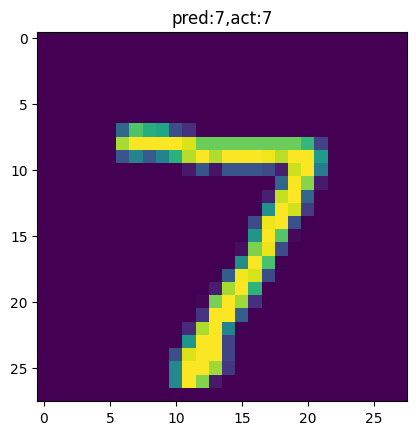

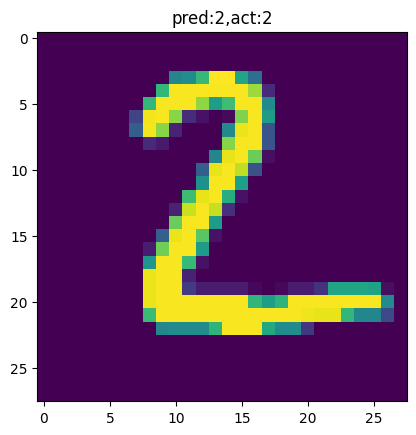

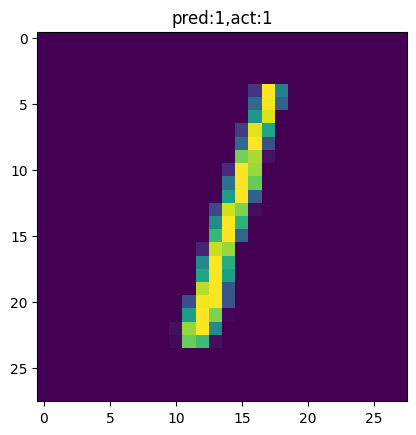

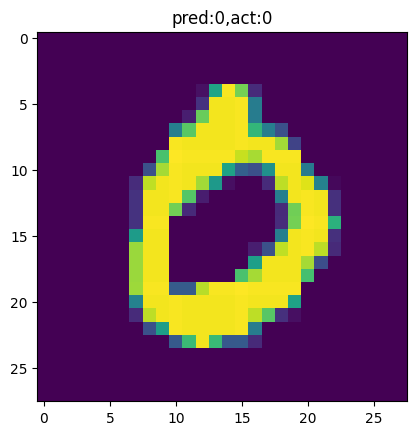

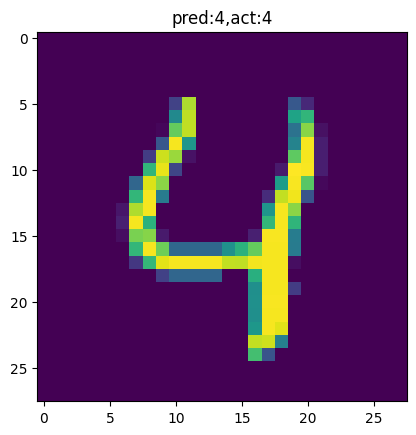

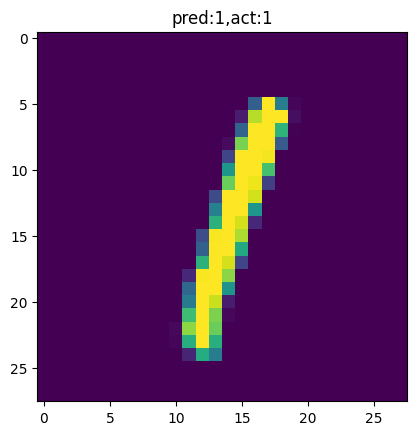

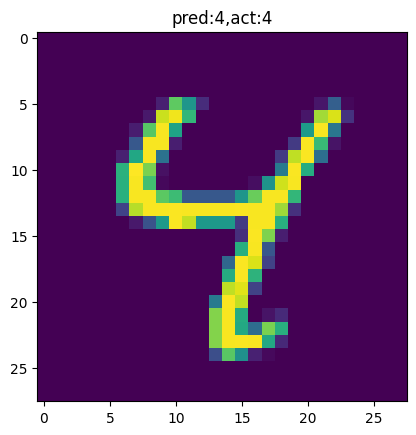

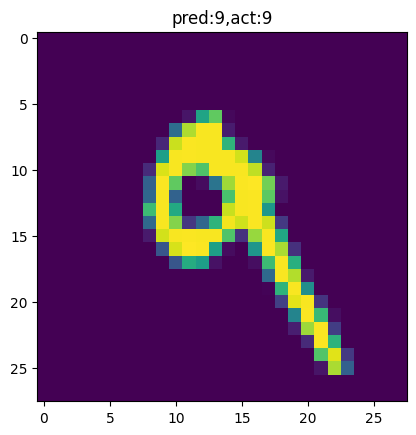

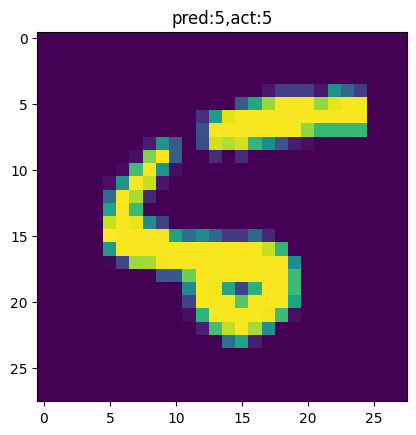

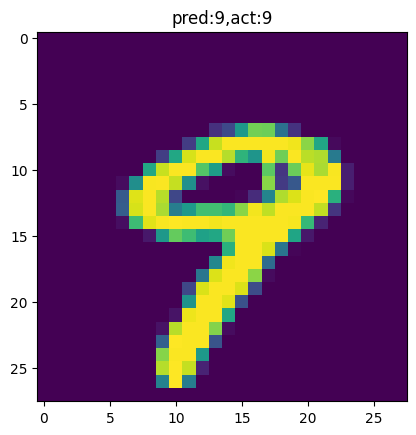

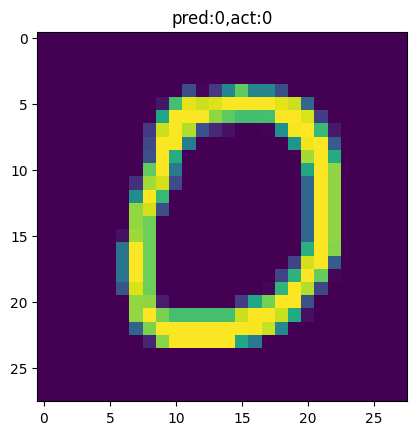

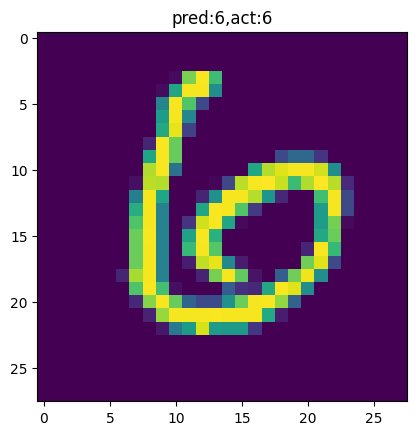

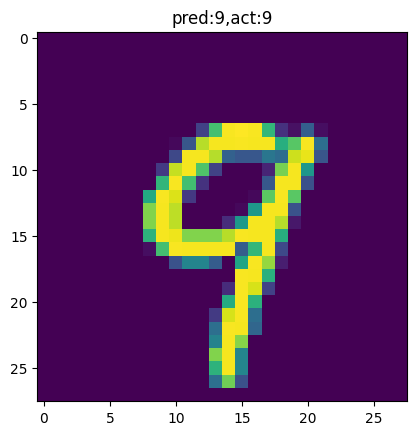

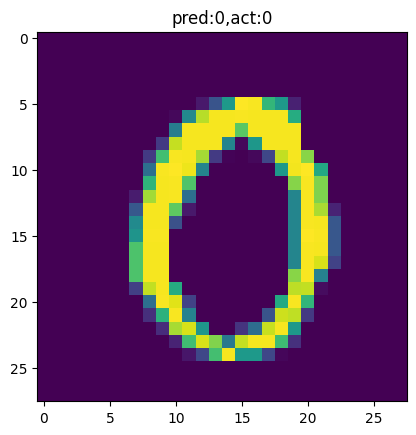

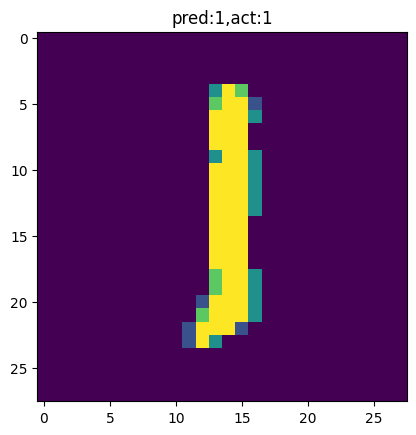

In [28]:
for i in range(15):
  plt.imshow(x_test[i].reshape(28,28))
  plt.title(f"pred:{pred_classes[i]},act:{act_classes[i]}")
  plt.show()
#

# **fashoin mnist dataset**

In [22]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

In [23]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)



(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [24]:
class_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

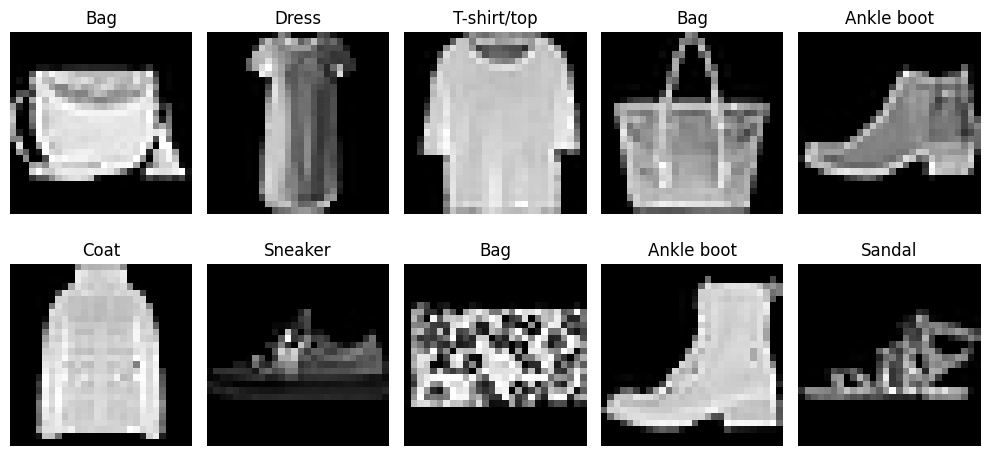

In [25]:
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
# x_train = x_train / 255.0
# x_test = x_test / 255.0

#normalize and reshape
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float32')/255
#one hot encoding labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
#

(60000, 28, 28, 1) (60000, 10)
(10000, 28, 28, 1) (10000, 10)


In [27]:
labels = np.argmax(y_train, axis=1)

class_counts = np.bincount(labels)#np.bincount() counts how many times each number appears.

for i in range(len(class_names)):
    print(class_names[i], ":", class_counts[i])

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


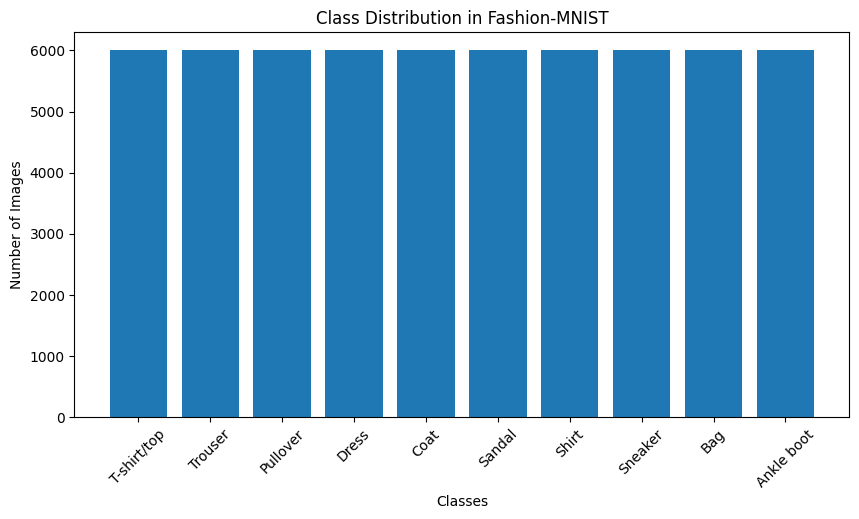

In [28]:
plt.figure(figsize=(10,5))

plt.bar(class_names, class_counts)

plt.xticks(rotation=45)
plt.title("Class Distribution in Fashion-MNIST")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

# **architecture**
Input (28x28x1)

Conv2D (32 filters, 3x3)

ReLU

MaxPooling (2x2)

Conv2D (64 filters, 3x3)

ReLU

MaxPooling (2x2)

Flatten

Dense (128)

Softmax (10)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([


    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:
history=model.fit(x_train, y_train, epochs=10,batch_size=128,validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7156 - loss: 0.8371 - val_accuracy: 0.8593 - val_loss: 0.4041
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8631 - loss: 0.3791 - val_accuracy: 0.8758 - val_loss: 0.3491
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8826 - loss: 0.3228 - val_accuracy: 0.8914 - val_loss: 0.3052
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8942 - loss: 0.2858 - val_accuracy: 0.8913 - val_loss: 0.3052
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9082 - loss: 0.2584 - val_accuracy: 0.9010 - val_loss: 0.2758
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9154 - loss: 0.2328 - val_accuracy: 0.9013 - val_loss: 0.2723
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9184 - loss: 0.2242 - val_accuracy: 0.9066 - val_loss: 0.2679
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9282 - loss: 0.2020 - val_accuracy: 0.

In [33]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Tested Acc:",test_acc)
print("Tested Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9029 - loss: 0.2742
Tested Acc: 0.9068999886512756
Tested Loss: 0.26060929894447327


In [34]:
pred=model.predict(x_test[:15])
pred_classes=np.argmax(pred,axis=1)
act_classes=np.argmax(y_test[:15],axis=1)
print(pred_classes)
print(act_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4]
[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4]


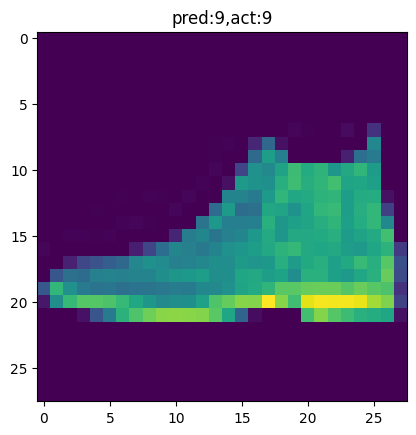

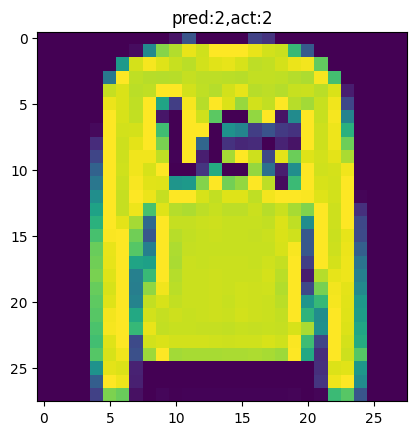

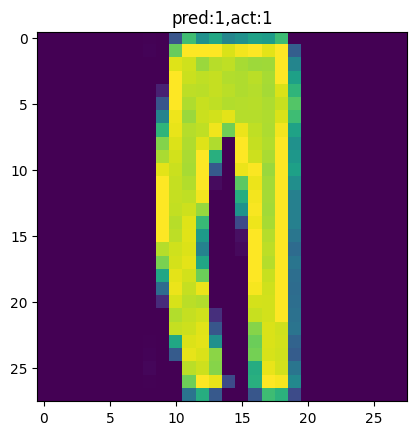

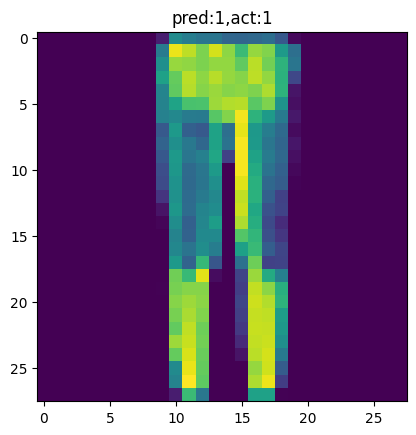

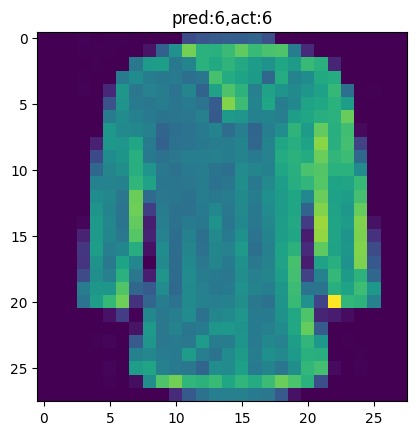

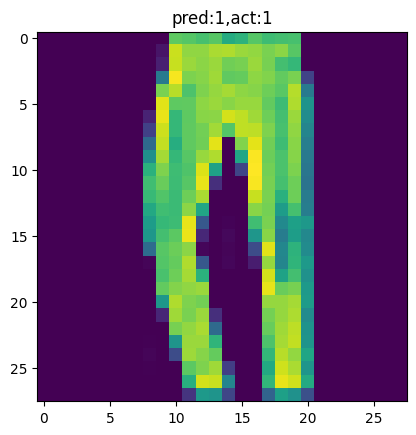

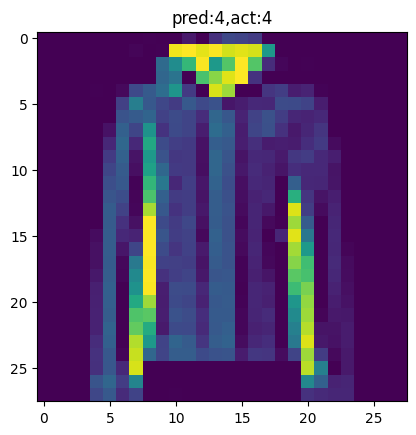

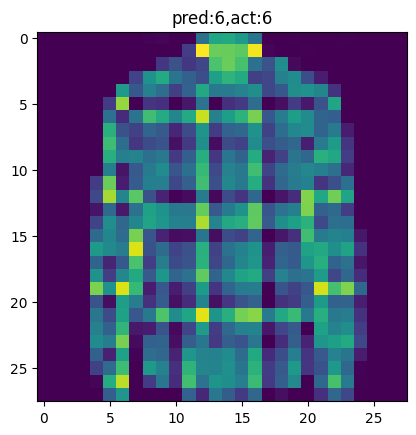

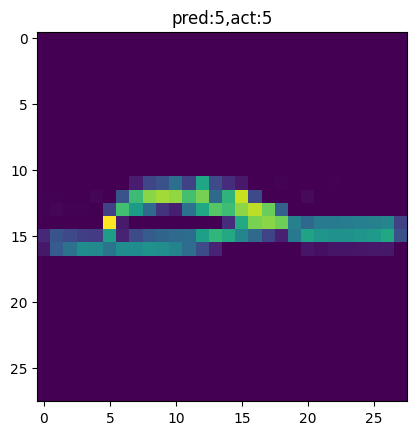

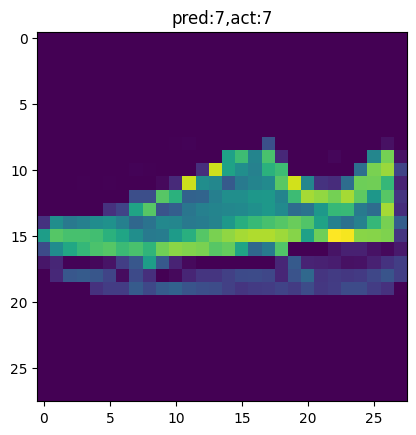

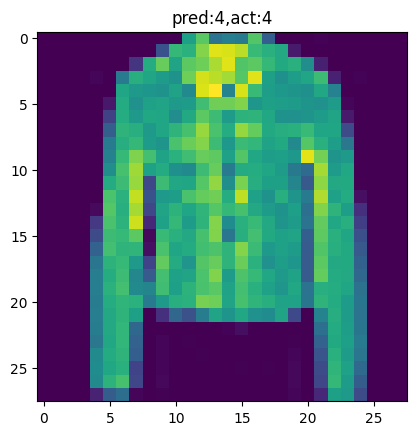

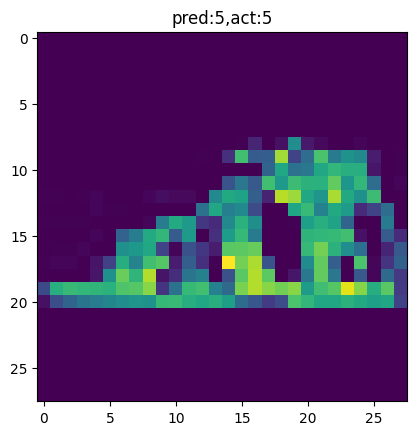

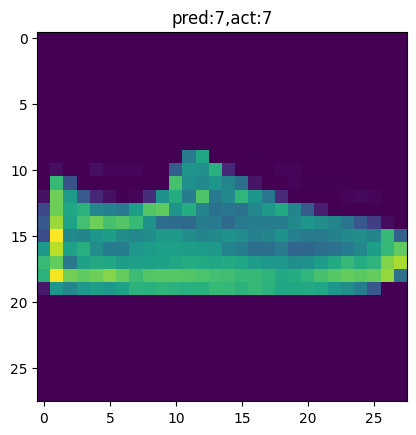

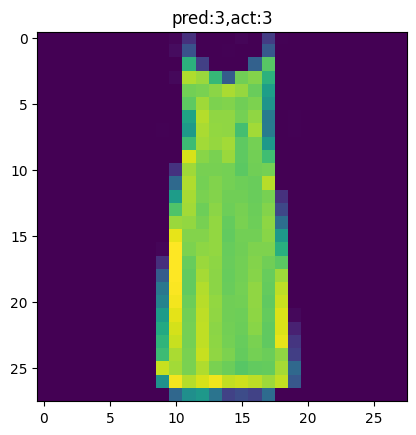

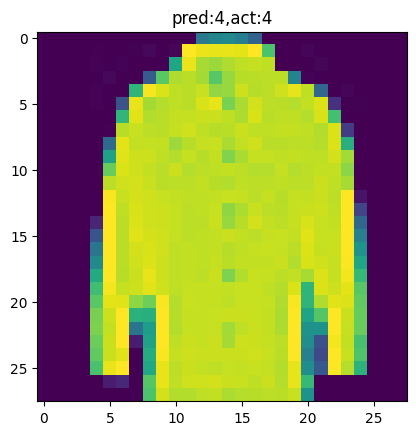

In [37]:
for i in range(15):
  plt.imshow(x_test[i].reshape(28,28))
  plt.title(f"pred:{pred_classes[i]},act:{act_classes[i]}")
  plt.show()
#

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(act_classes, pred_classes)

print(cm)

[[3 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 3 0 0 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]]


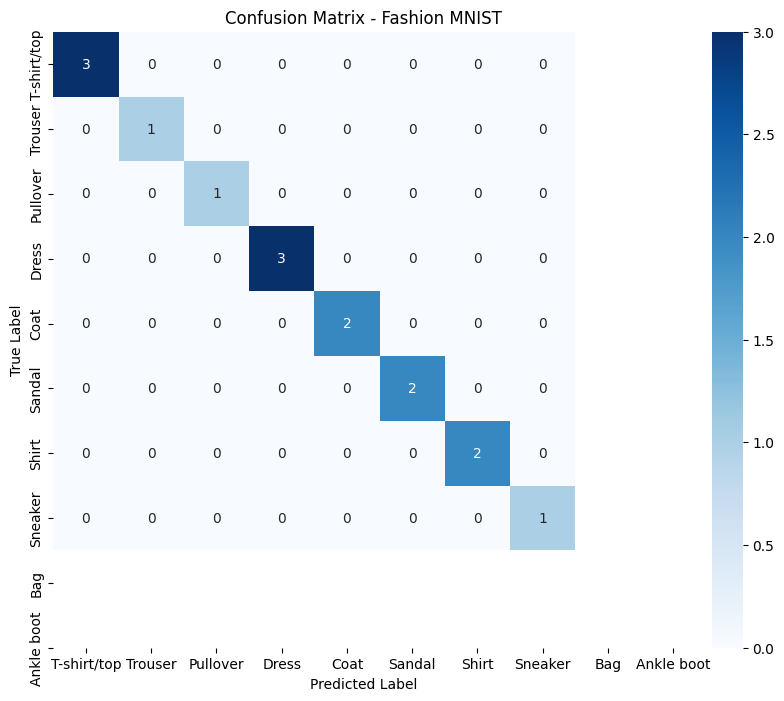

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fashion MNIST")

plt.show()

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
history2 = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7170 - loss: 0.7915 - val_accuracy: 0.8683 - val_loss: 0.3566
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8599 - loss: 0.3894 - val_accuracy: 0.8850 - val_loss: 0.3146
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8803 - loss: 0.3346 - val_accuracy: 0.8971 - val_loss: 0.2808
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8923 - loss: 0.3029 - val_accuracy: 0.9035 - val_loss: 0.2647
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9013 - loss: 0.2686 - val_accuracy: 0.9019 - val_loss: 0.2625
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9059 - loss: 0.2558 - val_accuracy: 0.9022 - val_loss: 0.2726
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9117 - loss: 0.2439 - val_accuracy: 0.9034 - val_loss: 0.2618
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9180 - loss: 0.2206 -

In [47]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Tested Acc:",test_acc)
print("Tested Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9082 - loss: 0.2756
Tested Acc: 0.9079999923706055
Tested Loss: 0.273110568523407


In [48]:
import numpy as np

y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [49]:
misclassified = np.where(y_pred_classes != y_true)[0]

print("Total misclassified images:", len(misclassified))

Total misclassified images: 920


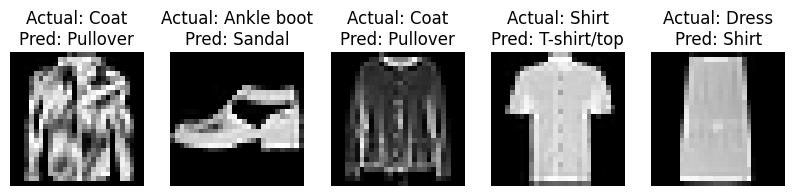

In [50]:
import matplotlib.pyplot as plt

class_names = [
'T-shirt/top','Trouser','Pullover','Dress','Coat',
'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

plt.figure(figsize=(10,5))

for i in range(5):

    index = misclassified[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')

    plt.title(
        f"Actual: {class_names[y_true[index]]}\nPred: {class_names[y_pred_classes[index]]}"
    )

    plt.axis('off')

plt.show()

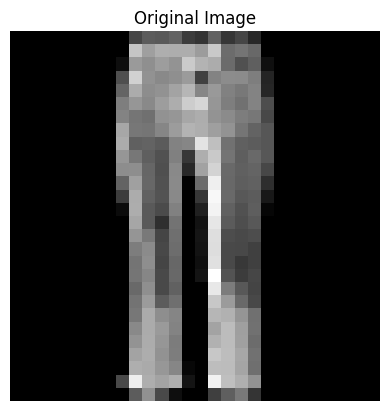

In [51]:
import numpy as np
import matplotlib.pyplot as plt

index = np.random.randint(0, len(x_test))

image = x_test[index]

plt.imshow(image.reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [54]:
model.predict(x_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step


array([[1.1463232e-12, 5.8691485e-16, 8.6155753e-15, 4.1104311e-15,
        2.0221063e-14, 3.8527978e-07, 4.3093429e-13, 4.7036878e-08,
        8.6661472e-13, 9.9999952e-01]], dtype=float32)

In [57]:
from tensorflow.keras.models import Model


model.predict(x_test[:1])

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

feature_model = Model(inputs=model.inputs, outputs=layer_outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


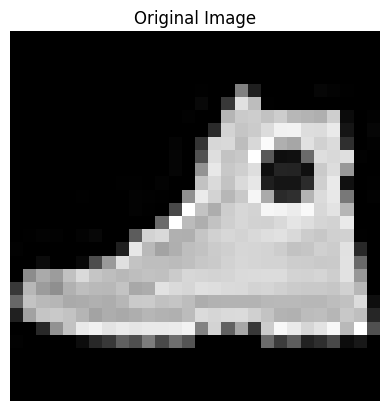

In [59]:
import numpy as np
import matplotlib.pyplot as plt

index = np.random.randint(0, len(x_test))
image = x_test[index]

plt.imshow(image.reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [60]:
feature_maps = feature_model.predict(image.reshape(1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step


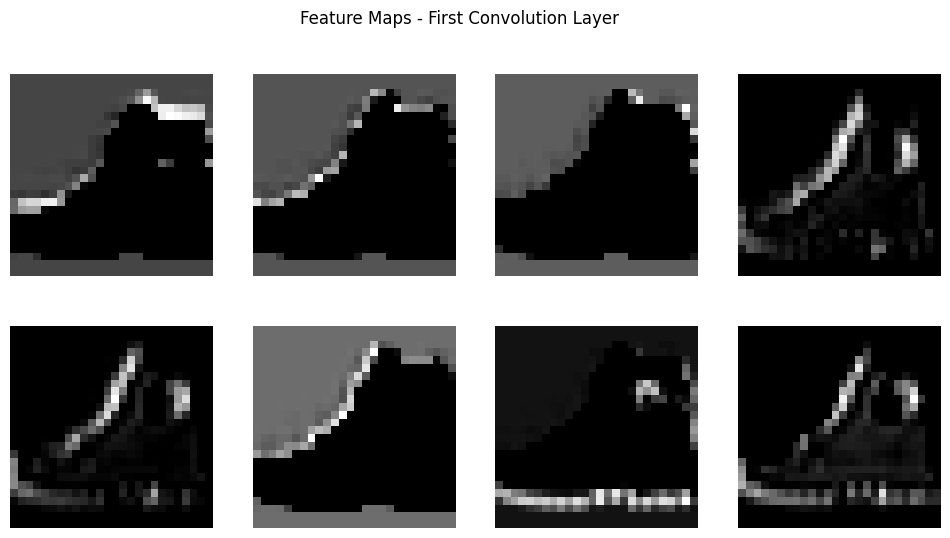

In [61]:
feature_layer = feature_maps[0]

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_layer[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps - First Convolution Layer")
plt.show()

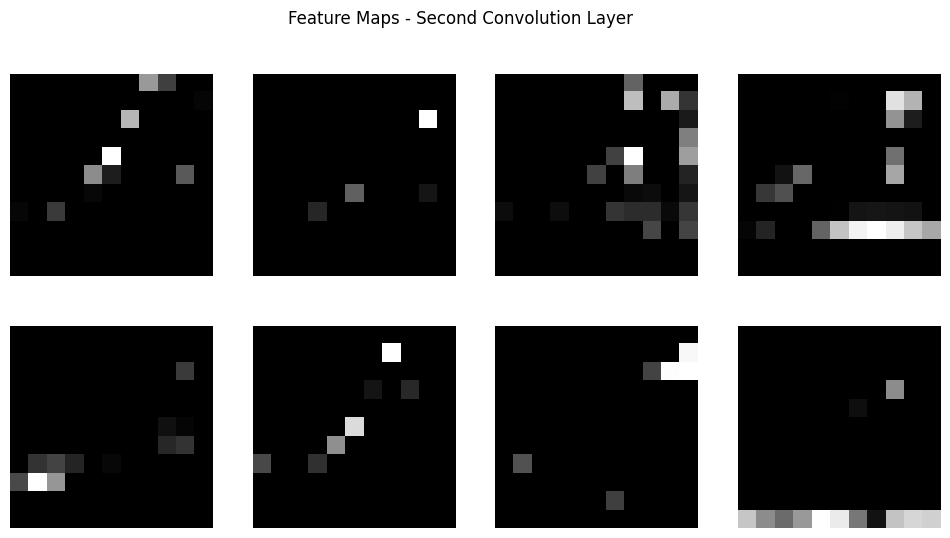

In [62]:
feature_layer = feature_maps[1]

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_layer[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps - Second Convolution Layer")
plt.show()

In [63]:
import numpy as np
import matplotlib.pyplot as plt

index = np.random.randint(0, len(x_test))

image = x_test[index]

In [64]:
prediction = model.predict(image.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


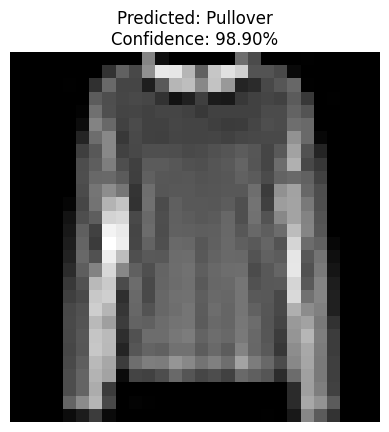

In [65]:
plt.imshow(image.reshape(28,28), cmap='gray')

plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence*100:.2f}%"
)

plt.axis('off')
plt.show()